# Ablation Study Analysis (3 × 3 Full Suite)

This notebook quantifies the contribution of each algorithmic component across **all 9 (dataset × hardware) combinations**.

| ID | Experiment | Component removed |
|---|---|---|
| T1 | `full_proposed` | — (baseline) |
| T2 | `no_pso` | Discrete PSO velocity update |
| T3 | `no_ga` | Genetic Algorithm crossover / mutation |
| T4 | `no_moead` | MOEA/D decomposition framework |
| T5 | `no_sa` | Simulated Annealing local refinement |
| T6 | `no_restart` | Population diversity restart mechanism |

**Structure:** 9 panels (CIFAR-10 / CIFAR-100 / ImageNet-16 × EdgeGPU / RPi-4 / Eyeriss)  
**Statistics:** Wilcoxon rank-sum tests with Bonferroni correction (α=0.05, 5 comparisons per combo)  
**Outputs:** HV/IGD 3×3 boxplot grids, significance heatmap, aggregate Pareto overlay.


In [1]:
# ── Cell 1: Setup ───────────────────────────────────────────────────────────
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / 'src').exists() and (_parent / 'requirements.txt').exists():
        PROJECT_ROOT = _parent
        break
else:
    PROJECT_ROOT = _cwd.parent

sys.path.insert(0, str(PROJECT_ROOT))
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import ranksums

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, proxy_pareto,
)
from src.analysis.data_loader import (
    DATASETS, HARDWARE,
    load_ablation_archives as _load_ablation_archives,
)
from src.utils.pareto_math import compute_bounds, normalise_to_bounds

ABLATION_DIR = PROJECT_ROOT / 'results' / 'ablations'
OUT_DIR      = PROJECT_ROOT / 'results' / 'figures' / 'ablation'
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size':  10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Experiment catalogue ────────────────────────────────────────────────────
EXPERIMENT_ORDER = [
    ('full_proposed', 'T1: Full'),
    ('no_pso',        'T2: No PSO'),
    ('no_ga',         'T3: No GA'),
    ('no_moead',      'T4: No MOEA/D'),
    ('no_sa',         'T5: No SA'),
    ('no_restart',    'T6: No Restart'),
]
EXP_NAMES  = [n for n, _ in EXPERIMENT_ORDER]
EXP_LABELS = {n: l for n, l in EXPERIMENT_ORDER}
EXP_SHORT  = {n: l.split(': ')[1] for n, l in EXPERIMENT_ORDER}

COLORS = {
    'full_proposed': '#1f77b4',
    'no_pso':        '#ff7f0e',
    'no_ga':         '#2ca02c',
    'no_moead':      '#d62728',
    'no_sa':         '#9467bd',
    'no_restart':    '#8c564b',
}

DS_LABEL = {
    'cifar10':        'CIFAR-10',
    'cifar100':       'CIFAR-100',
    'ImageNet16-120': 'ImageNet-16',
}
HW_LABEL = {
    'edgegpu_latency': 'EdgeGPU',
    'raspi4_latency':  'RPi-4',
    'eyeriss_latency': 'Eyeriss',
}

REF = np.array([1.1, 1.1])
print('Setup complete.')


PROJECT_ROOT = /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic
Setup complete.


In [2]:
# ── Cell 2: Load ablation archives ─────────────────────────────────────────
# available[dataset][hardware][exp_name] = list of per-seed archive lists
available = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}

print('Loading ablation archives ...')
total = 0
for ds in DATASETS:
    for hw in HARDWARE:
        combo_dir = ABLATION_DIR / ds / hw
        for name in EXP_NAMES:
            arcs = _load_ablation_archives(combo_dir, name) if combo_dir.exists() else []
            available[ds][hw][name] = arcs
        n = sum(len(available[ds][hw][n]) for n in EXP_NAMES)
        total += n
        print(f'  [{DS_LABEL[ds]:<12} x {HW_LABEL[hw]:<8}]  {n:3d} seed files')

print(f'\nTotal: {total} seed archives across {len(DATASETS)*len(HARDWARE)} combos.')


Loading ablation archives ...
  [CIFAR-10     x EdgeGPU ]  180 seed files
  [CIFAR-10     x RPi-4   ]  180 seed files
  [CIFAR-10     x Eyeriss ]  180 seed files
  [CIFAR-100    x EdgeGPU ]  180 seed files
  [CIFAR-100    x RPi-4   ]  180 seed files
  [CIFAR-100    x Eyeriss ]  180 seed files
  [ImageNet-16  x EdgeGPU ]  180 seed files
  [ImageNet-16  x RPi-4   ]  180 seed files
  [ImageNet-16  x Eyeriss ]  180 seed files

Total: 1620 seed archives across 9 combos.


In [3]:
# ── Cell 3: Per-combo proxy P* + HV/IGD per seed ────────────────────────────
# all_metrics[dataset][hardware][exp_name] = {'hv': array, 'igd': array}
all_metrics = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}

N_COMBO = len(DATASETS) * len(HARDWARE)
done = 0
print('Computing HV and IGD per seed ...\n')

for ds in DATASETS:
    for hw in HARDWARE:
        done += 1
        tag = f'[{DS_LABEL[ds]:<12} x {HW_LABEL[hw]:<8}]  ({done}/{N_COMBO})'

        all_runs = [a for n in EXP_NAMES for a in available[ds][hw][n]]
        if not all_runs:
            print(f'{tag}  SKIP (no data)')
            continue

        try:
            p_star = proxy_pareto(all_runs)
        except Exception as exc:
            print(f'{tag}  SKIP (proxy_pareto failed: {exc})')
            continue

        bmin, brange = compute_bounds(p_star)
        p_star_n     = normalise_to_bounds(p_star, bmin, brange)

        print(f'{tag}')
        for name in EXP_NAMES:
            arcs = available[ds][hw][name]
            if not arcs:
                all_metrics[ds][hw][name] = {'hv': np.array([]), 'igd': np.array([])}
                print(f'    {EXP_SHORT[name]:<12}  (empty)')
                continue
            hvs, igds = [], []
            for run in arcs:
                pts   = archive_to_points(run)
                front = get_pareto_front(pts)
                nf    = normalise_to_bounds(front, bmin, brange)
                hvs.append(calc_hv(nf, ref_point=REF))
                igds.append(calc_igd(nf, p_star_n))
            all_metrics[ds][hw][name] = {
                'hv':  np.array(hvs),
                'igd': np.array(igds),
            }
            m = all_metrics[ds][hw][name]
            print(f'    {EXP_SHORT[name]:<12}  '
                  f'HV {m["hv"].mean():.4f}\u00b1{m["hv"].std():.4f}  '
                  f'IGD {m["igd"].mean():.4f}\u00b1{m["igd"].std():.4f}  '
                  f'(n={len(hvs)})')

print('\nAll combos processed.')


Computing HV and IGD per seed ...

[CIFAR-10     x EdgeGPU ]  (1/9)

Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

    Full          HV 1.0468±0.0010  IGD 0.0095±0.0061  (n=30)
    No PSO        HV 1.0480±0.0007  IGD 0.0055±0.0029  (n=30)
    No GA         HV 0.8651±0.1278  IGD 0.1226±0.0371  (n=30)
    No MOEA/D     HV 1.0421±0.0047  IGD 0.0353±0.0275  (n=30)
    No SA         HV 1.0469±0.0011  IGD 0.0097±0.0070  (n=30)
    No Restart    HV 1.0468±0.0011  IGD 0.0097±0.0057  (n=30)
[CIFAR-10     x RPi-4   ]  (2/9)
    Full          HV 1.1559±0.0012  IGD 0.0159±0.0210  (n=30)
    No PSO        HV 1.1573±0.0005  IGD 0.0037±0.0051  (n=30)
    No GA         HV 1.1101±0.0336  IGD 0.1072±0.0391  (n=30)
    No MOEA/D     HV 1.1523±0.0025  IGD 0.0531±0.0188  (n=30)
    No SA         HV 1.1561±0.0010  IGD 0.0089±0.0098  (n=30)
    No Res

In [4]:
# ── Cell 4: Summary pivot table (mean HV across all combos) ─────────────────
records = []
for ds in DATASETS:
    for hw in HARDWARE:
        for name in EXP_NAMES:
            m    = all_metrics[ds][hw].get(name, {})
            hvs  = m.get('hv',  np.array([]))
            igds = m.get('igd', np.array([]))
            records.append({
                'Dataset':    DS_LABEL[ds],
                'Hardware':   HW_LABEL[hw],
                'Experiment': EXP_LABELS[name],
                'exp_name':   name,
                'hv_mean':    hvs.mean()  if len(hvs)  else float('nan'),
                'hv_std':     hvs.std()   if len(hvs)  else float('nan'),
                'igd_mean':   igds.mean() if len(igds) else float('nan'),
                'igd_std':    igds.std()  if len(igds) else float('nan'),
                'n_seeds':    len(hvs),
            })

df = pd.DataFrame(records)

pivot_hv = df.pivot_table(
    index='Experiment',
    columns=['Dataset', 'Hardware'],
    values='hv_mean',
    aggfunc='mean',
).reindex([EXP_LABELS[n] for n in EXP_NAMES])

print('Mean Hypervolume \u2191 across 9 (dataset x hardware) combinations:\n')
print(pivot_hv.round(4).to_string())

print('\nMean IGD \u2193:')
pivot_igd = df.pivot_table(
    index='Experiment',
    columns=['Dataset', 'Hardware'],
    values='igd_mean',
    aggfunc='mean',
).reindex([EXP_LABELS[n] for n in EXP_NAMES])
print(pivot_igd.round(4).to_string())


Mean Hypervolume ↑ across 9 (dataset x hardware) combinations:

Dataset        CIFAR-10                 CIFAR-100                 ImageNet-16                
Hardware        EdgeGPU Eyeriss   RPi-4   EdgeGPU Eyeriss   RPi-4     EdgeGPU Eyeriss   RPi-4
Experiment                                                                                   
T1: Full         1.0468  1.0148  1.1559    1.0187  1.0253  1.1292      0.9797  0.9477  0.9929
T2: No PSO       1.0480  1.0246  1.1573    1.0206  1.0332  1.1333      0.9844  0.9637  1.0000
T3: No GA        0.8651  0.8493  1.1101    0.8273  0.8000  1.0644      0.7665  0.6725  0.8563
T4: No MOEA/D    1.0421  0.9923  1.1523    1.0110  1.0013  1.1207      0.9632  0.8948  0.9850
T5: No SA        1.0469  1.0178  1.1561    1.0191  1.0274  1.1300      0.9792  0.9482  0.9949
T6: No Restart   1.0468  1.0156  1.1559    1.0186  1.0248  1.1294      0.9798  0.9465  0.9928

Mean IGD ↓:
Dataset        CIFAR-10                 CIFAR-100                 ImageNet-16

In [5]:
# ── Cell 5: Wilcoxon rank-sum tests per combo (T1 vs T2-T6) ────────────────
N_TESTS = len(EXP_NAMES) - 1  # 5 ablations (Bonferroni correction)

stat_records = []
for ds in DATASETS:
    for hw in HARDWARE:
        hv1 = all_metrics[ds][hw].get('full_proposed', {}).get('hv', np.array([]))
        if len(hv1) == 0:
            continue
        for name in EXP_NAMES[1:]:
            hv2 = all_metrics[ds][hw].get(name, {}).get('hv', np.array([]))
            if len(hv2) == 0:
                p_raw, stat = 1.0, 0.0
            else:
                try:
                    stat, p_raw = ranksums(hv1, hv2)
                except ValueError:
                    p_raw, stat = 1.0, 0.0
            p_bonf = min(p_raw * N_TESTS, 1.0)
            sig    = ('***' if p_bonf < 0.001 else
                      '**'  if p_bonf < 0.01  else
                      '*'   if p_bonf < 0.05  else 'n.s.')
            stat_records.append({
                'Dataset':   DS_LABEL[ds],
                'Hardware':  HW_LABEL[hw],
                'Ablation':  EXP_LABELS[name],
                'exp_name':  name,
                'ds_key':    ds,
                'hw_key':    hw,
                'W':         round(float(stat), 3),
                'p_raw':     float(p_raw),
                'p_bonf':    float(p_bonf),
                'sig':       sig,
                'delta_hv':  float(hv1.mean() - hv2.mean()) if len(hv2) else float('nan'),
            })

df_stats = pd.DataFrame(stat_records)

pivot_sig = df_stats.pivot_table(
    index='Ablation',
    columns=['Dataset', 'Hardware'],
    values='sig',
    aggfunc='first',
).reindex([EXP_LABELS[n] for n in EXP_NAMES[1:]])

print('Wilcoxon Rank-Sum  T1 Full vs ablation  (Bonferroni-corrected):\n')
print(pivot_sig.to_string())
print('\n*** p<0.001   ** p<0.01   * p<0.05   n.s. not significant')


Wilcoxon Rank-Sum  T1 Full vs ablation  (Bonferroni-corrected):

Dataset        CIFAR-10               CIFAR-100               ImageNet-16              
Hardware        EdgeGPU Eyeriss RPi-4   EdgeGPU Eyeriss RPi-4     EdgeGPU Eyeriss RPi-4
Ablation                                                                               
T2: No PSO          ***     ***   ***       ***     ***   ***         ***      **   ***
T3: No GA           ***     ***   ***       ***     ***   ***         ***     ***   ***
T4: No MOEA/D       ***     ***   ***       ***     ***   ***         ***     ***    **
T5: No SA          n.s.    n.s.  n.s.      n.s.    n.s.  n.s.        n.s.    n.s.  n.s.
T6: No Restart     n.s.    n.s.  n.s.      n.s.    n.s.  n.s.        n.s.    n.s.  n.s.

*** p<0.001   ** p<0.01   * p<0.05   n.s. not significant


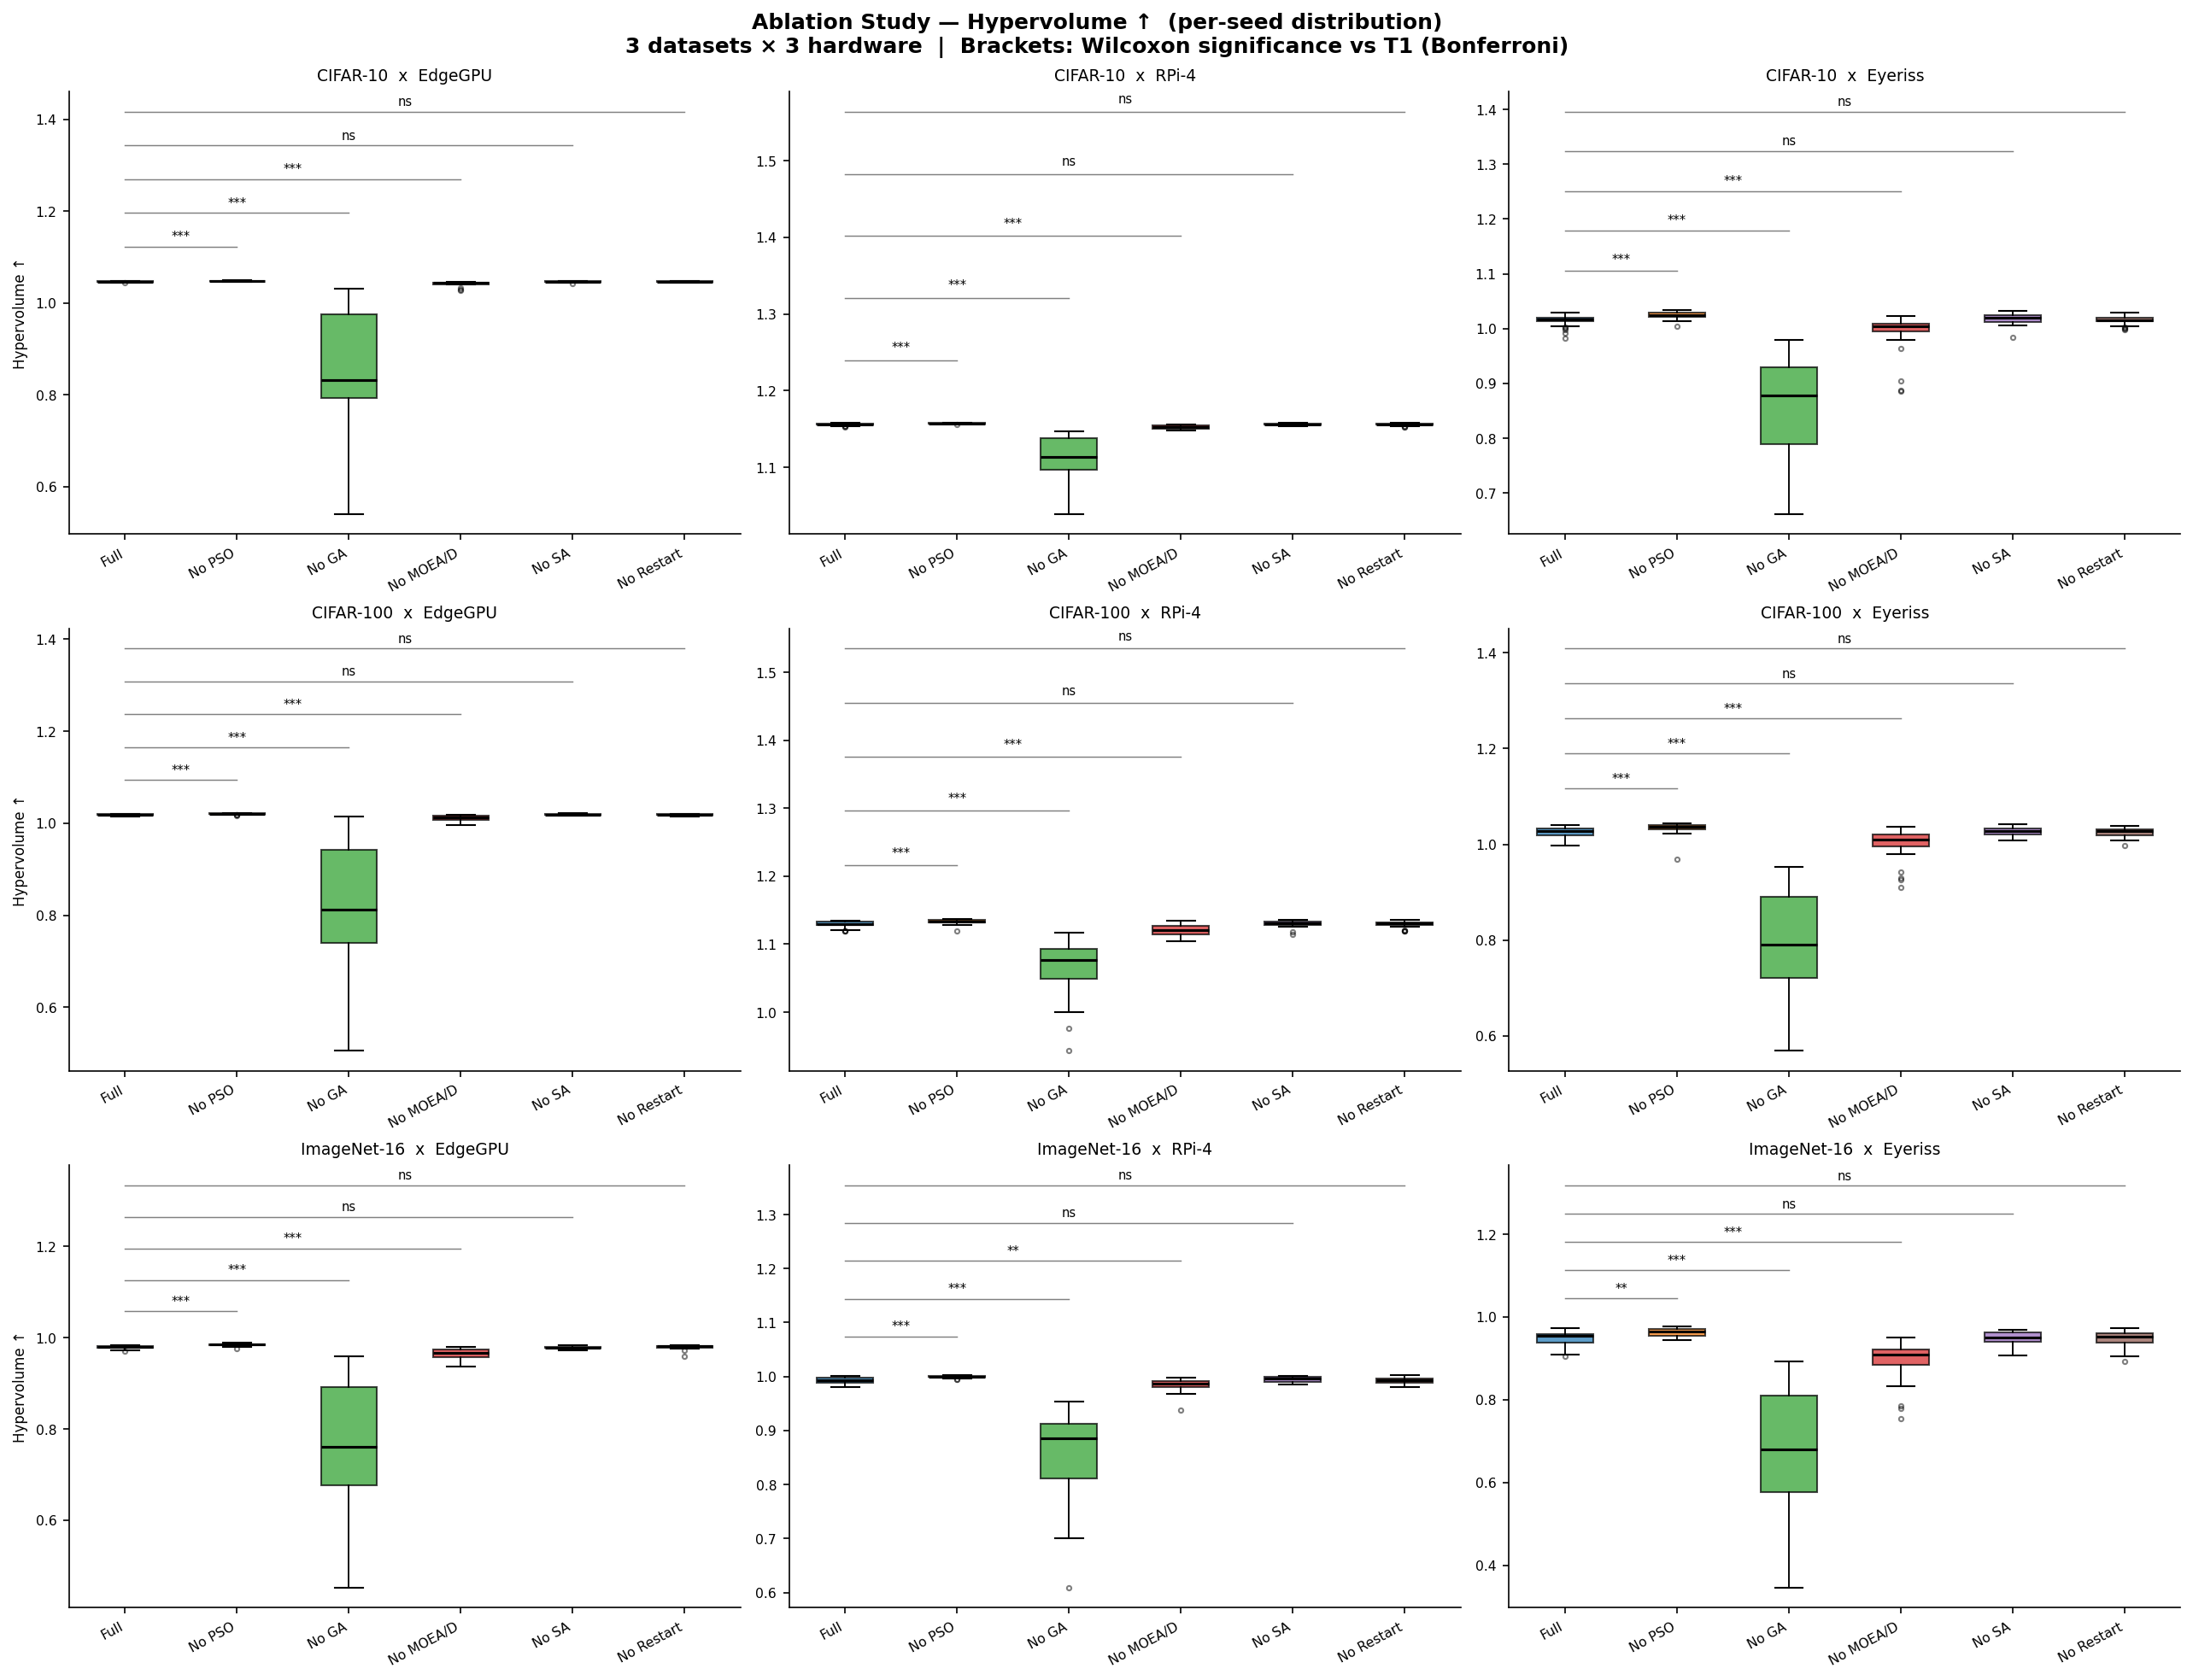

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/ablation/ablation_hv_3x3.pdf


In [6]:
# ── Cell 6: 3x3 Hypervolume box plot grid ───────────────────────────────────
fig_hv, axes_hv = plt.subplots(3, 3, figsize=(17, 13), constrained_layout=True)
fig_hv.suptitle(
    'Ablation Study \u2014 Hypervolume \u2191  (per-seed distribution)\n'
    '3 datasets \u00d7 3 hardware  |  Brackets: Wilcoxon significance vs T1 (Bonferroni)',
    fontsize=12, fontweight='bold',
)

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax = axes_hv[r, c]

        data, valid_names, valid_shorts, valid_colors = [], [], [], []
        for name in EXP_NAMES:
            vals = all_metrics[ds][hw].get(name, {}).get('hv', np.array([]))
            if len(vals) > 0:
                data.append(vals)
                valid_names.append(name)
                valid_shorts.append(EXP_SHORT[name])
                valid_colors.append(COLORS[name])

        if not data:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_title(f'{DS_LABEL[ds]}  x  {HW_LABEL[hw]}', fontsize=8)
            continue

        bp = ax.boxplot(
            data, patch_artist=True, notch=False,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(linewidth=0.9),
            flierprops=dict(marker='o', markersize=2.5, alpha=0.5),
        )
        for patch, col in zip(bp['boxes'], valid_colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.72)

        # Significance brackets (T1 vs others)
        t1_pos = valid_names.index('full_proposed') + 1 if 'full_proposed' in valid_names else None
        if t1_pos is not None:
            y_max  = max(d.max() for d in data)
            y_step = max(abs(y_max) * 0.07, 1e-6)
            bar_level = 0
            for vi, name in enumerate(valid_names):
                if name == 'full_proposed':
                    continue
                row = df_stats[
                    (df_stats['ds_key'] == ds) &
                    (df_stats['hw_key'] == hw) &
                    (df_stats['exp_name'] == name)
                ]
                if row.empty:
                    continue
                sig    = row.iloc[0]['sig']
                marker = sig if sig != 'n.s.' else 'ns'
                x1, x2 = sorted([t1_pos, vi + 1])
                y_bar  = y_max + y_step * (bar_level + 1.0)
                ax.plot([x1, x2], [y_bar, y_bar], color='gray', lw=0.7)
                ax.text((x1 + x2) / 2, y_bar + y_step * 0.1, marker,
                        ha='center', va='bottom', fontsize=7)
                bar_level += 1

        ax.set_xticks(range(1, len(valid_shorts) + 1))
        ax.set_xticklabels(valid_shorts, fontsize=7.5, rotation=28, ha='right')
        ax.set_title(f'{DS_LABEL[ds]}  x  {HW_LABEL[hw]}', fontsize=9)
        if c == 0:
            ax.set_ylabel('Hypervolume \u2191', fontsize=8)
        ax.tick_params(axis='y', labelsize=7.5)

save_hv = OUT_DIR / 'ablation_hv_3x3.pdf'
plt.savefig(save_hv, bbox_inches='tight')
plt.show()
print(f'Saved: {save_hv}')


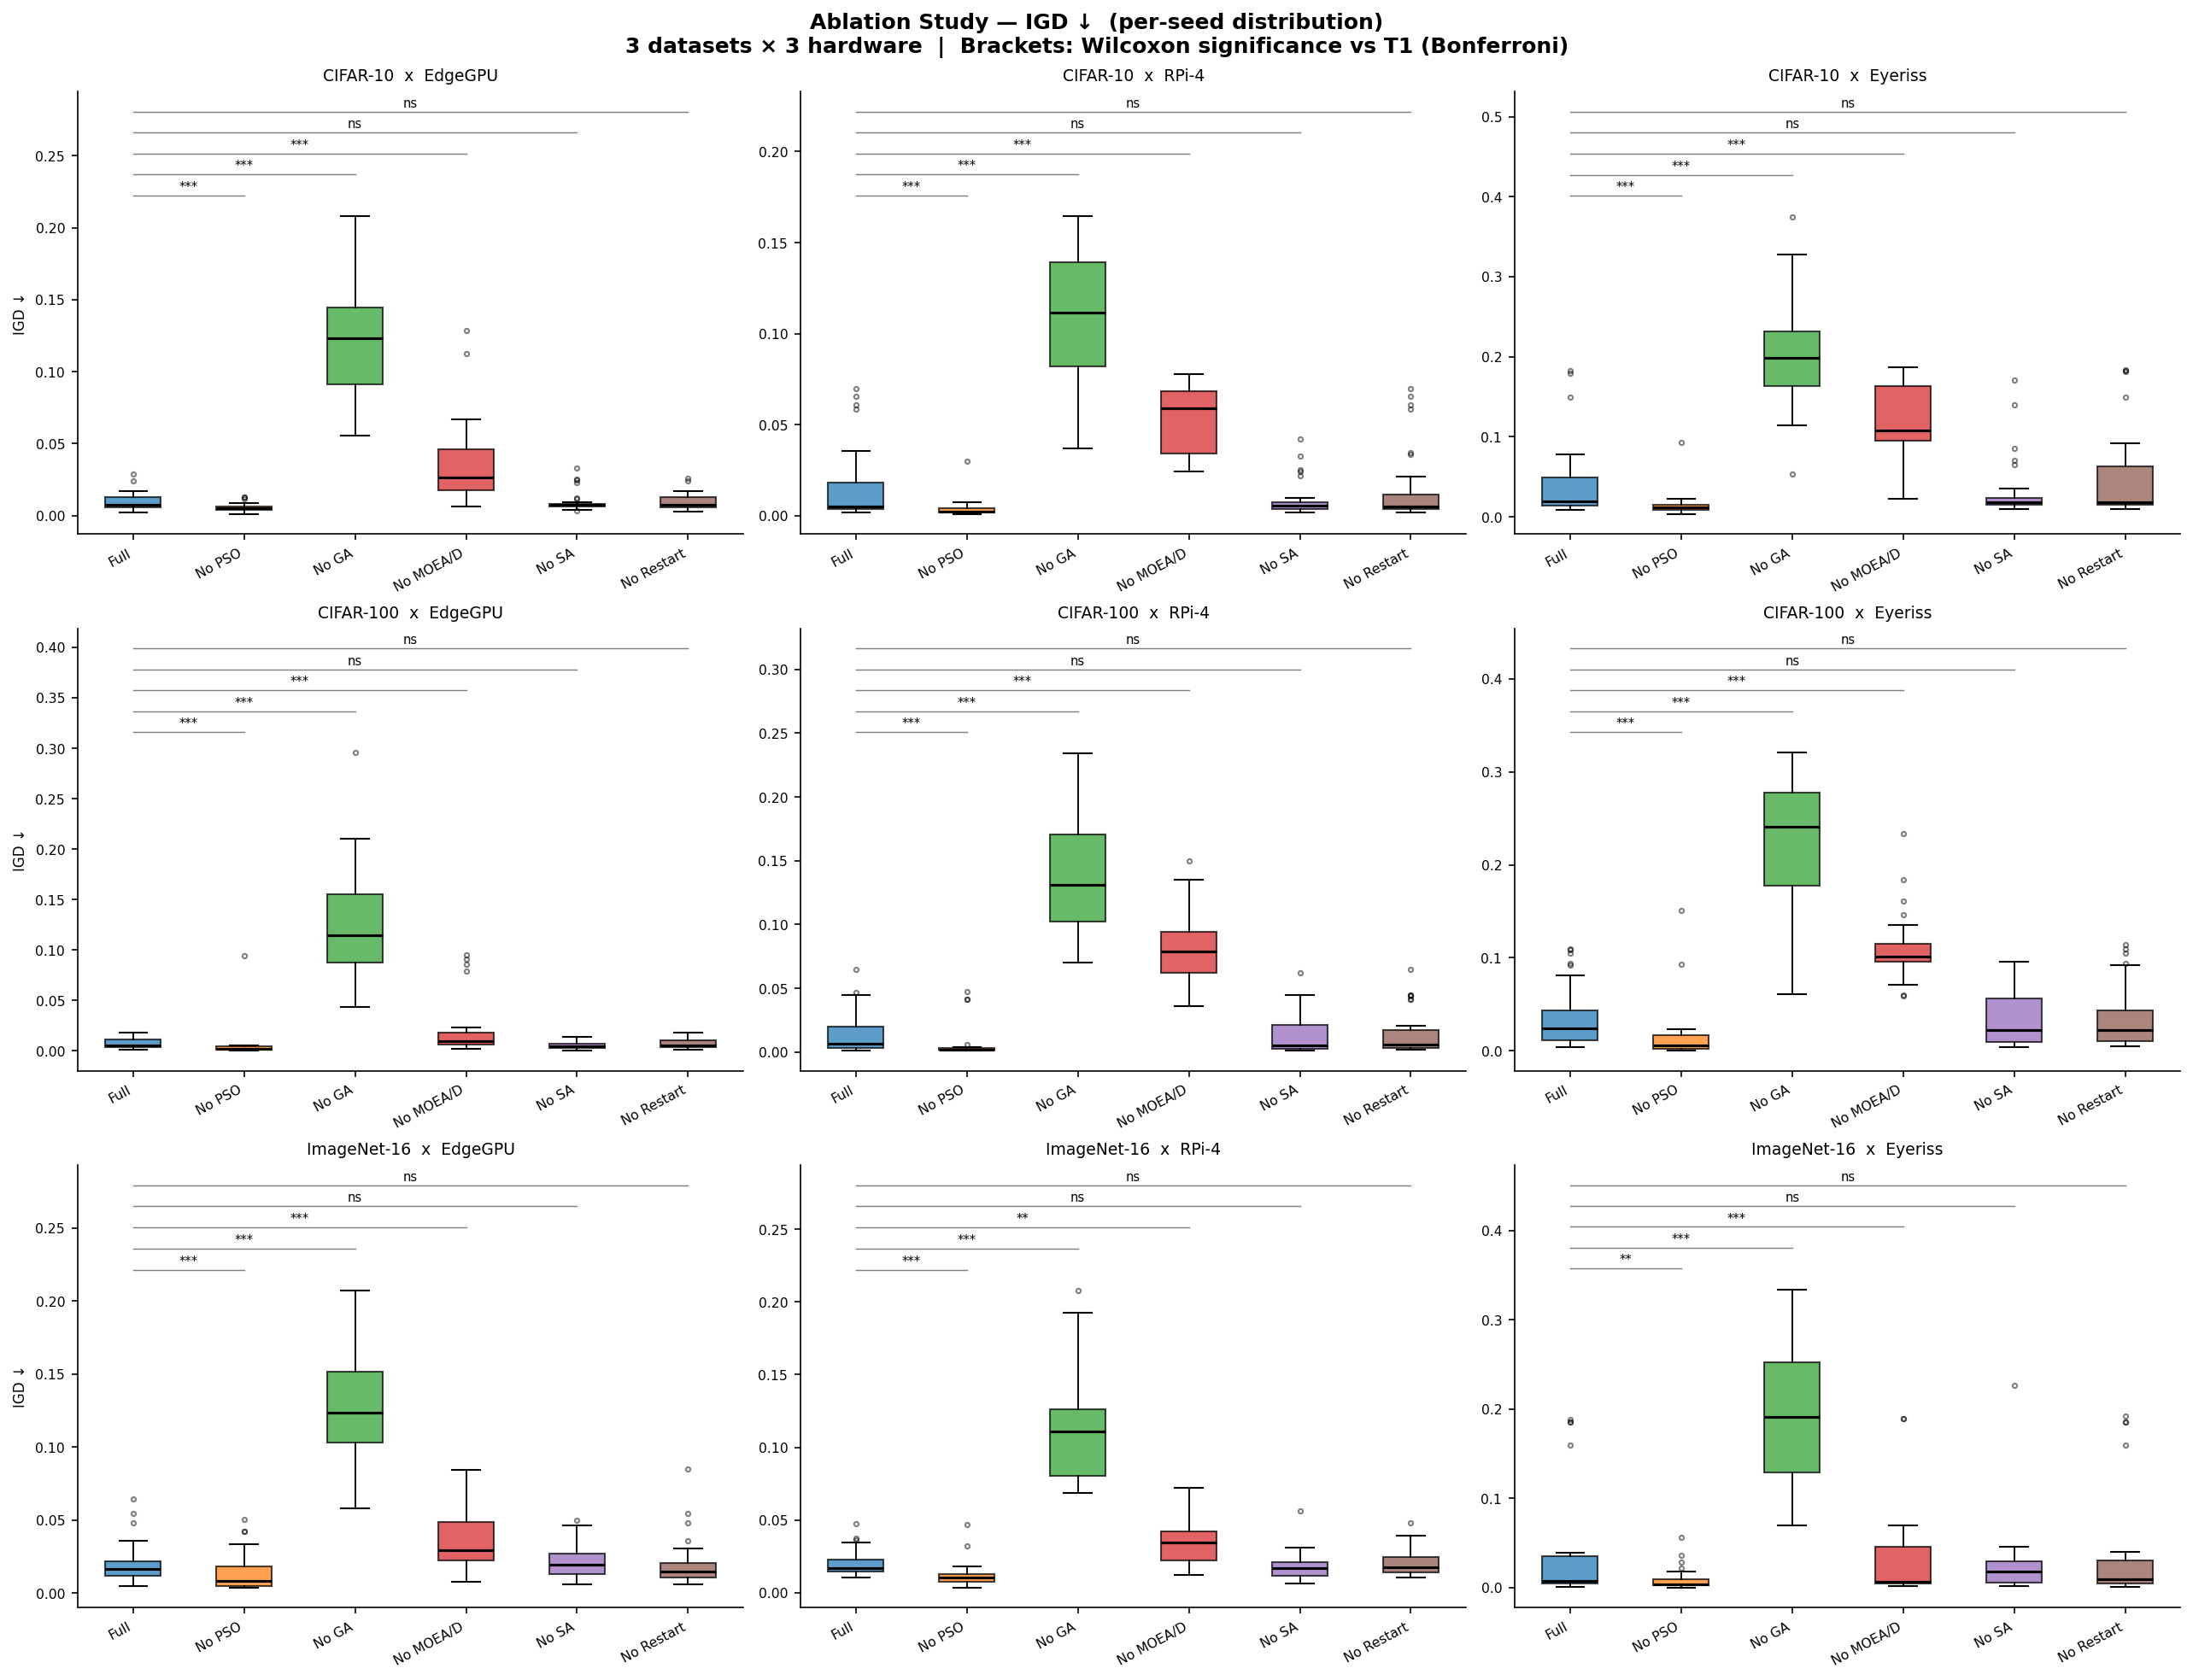

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/ablation/ablation_igd_3x3.pdf


In [7]:
# ── Cell 7: 3x3 IGD box plot grid ───────────────────────────────────────────
fig_igd, axes_igd = plt.subplots(3, 3, figsize=(17, 13), constrained_layout=True)
fig_igd.suptitle(
    'Ablation Study \u2014 IGD \u2193  (per-seed distribution)\n'
    '3 datasets \u00d7 3 hardware  |  Brackets: Wilcoxon significance vs T1 (Bonferroni)',
    fontsize=12, fontweight='bold',
)

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax = axes_igd[r, c]

        data, valid_names, valid_shorts, valid_colors = [], [], [], []
        for name in EXP_NAMES:
            vals = all_metrics[ds][hw].get(name, {}).get('igd', np.array([]))
            if len(vals) > 0:
                data.append(vals)
                valid_names.append(name)
                valid_shorts.append(EXP_SHORT[name])
                valid_colors.append(COLORS[name])

        if not data:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_title(f'{DS_LABEL[ds]}  x  {HW_LABEL[hw]}', fontsize=8)
            continue

        bp = ax.boxplot(
            data, patch_artist=True, notch=False,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(linewidth=0.9),
            flierprops=dict(marker='o', markersize=2.5, alpha=0.5),
        )
        for patch, col in zip(bp['boxes'], valid_colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.72)

        # Significance brackets for IGD (lower is better, T1 should have lower IGD)
        t1_pos = valid_names.index('full_proposed') + 1 if 'full_proposed' in valid_names else None
        if t1_pos is not None:
            y_max  = max(d.max() for d in data)
            y_step = max(abs(y_max) * 0.07, 1e-6)
            bar_level = 0
            for vi, name in enumerate(valid_names):
                if name == 'full_proposed':
                    continue
                row = df_stats[
                    (df_stats['ds_key'] == ds) &
                    (df_stats['hw_key'] == hw) &
                    (df_stats['exp_name'] == name)
                ]
                if row.empty:
                    continue
                sig    = row.iloc[0]['sig']
                marker = sig if sig != 'n.s.' else 'ns'
                x1, x2 = sorted([t1_pos, vi + 1])
                y_bar  = y_max + y_step * (bar_level + 1.0)
                ax.plot([x1, x2], [y_bar, y_bar], color='gray', lw=0.7)
                ax.text((x1 + x2) / 2, y_bar + y_step * 0.1, marker,
                        ha='center', va='bottom', fontsize=7)
                bar_level += 1

        ax.set_xticks(range(1, len(valid_shorts) + 1))
        ax.set_xticklabels(valid_shorts, fontsize=7.5, rotation=28, ha='right')
        ax.set_title(f'{DS_LABEL[ds]}  x  {HW_LABEL[hw]}', fontsize=9)
        if c == 0:
            ax.set_ylabel('IGD \u2193', fontsize=8)
        ax.tick_params(axis='y', labelsize=7.5)

save_igd = OUT_DIR / 'ablation_igd_3x3.pdf'
plt.savefig(save_igd, bbox_inches='tight')
plt.show()
print(f'Saved: {save_igd}')


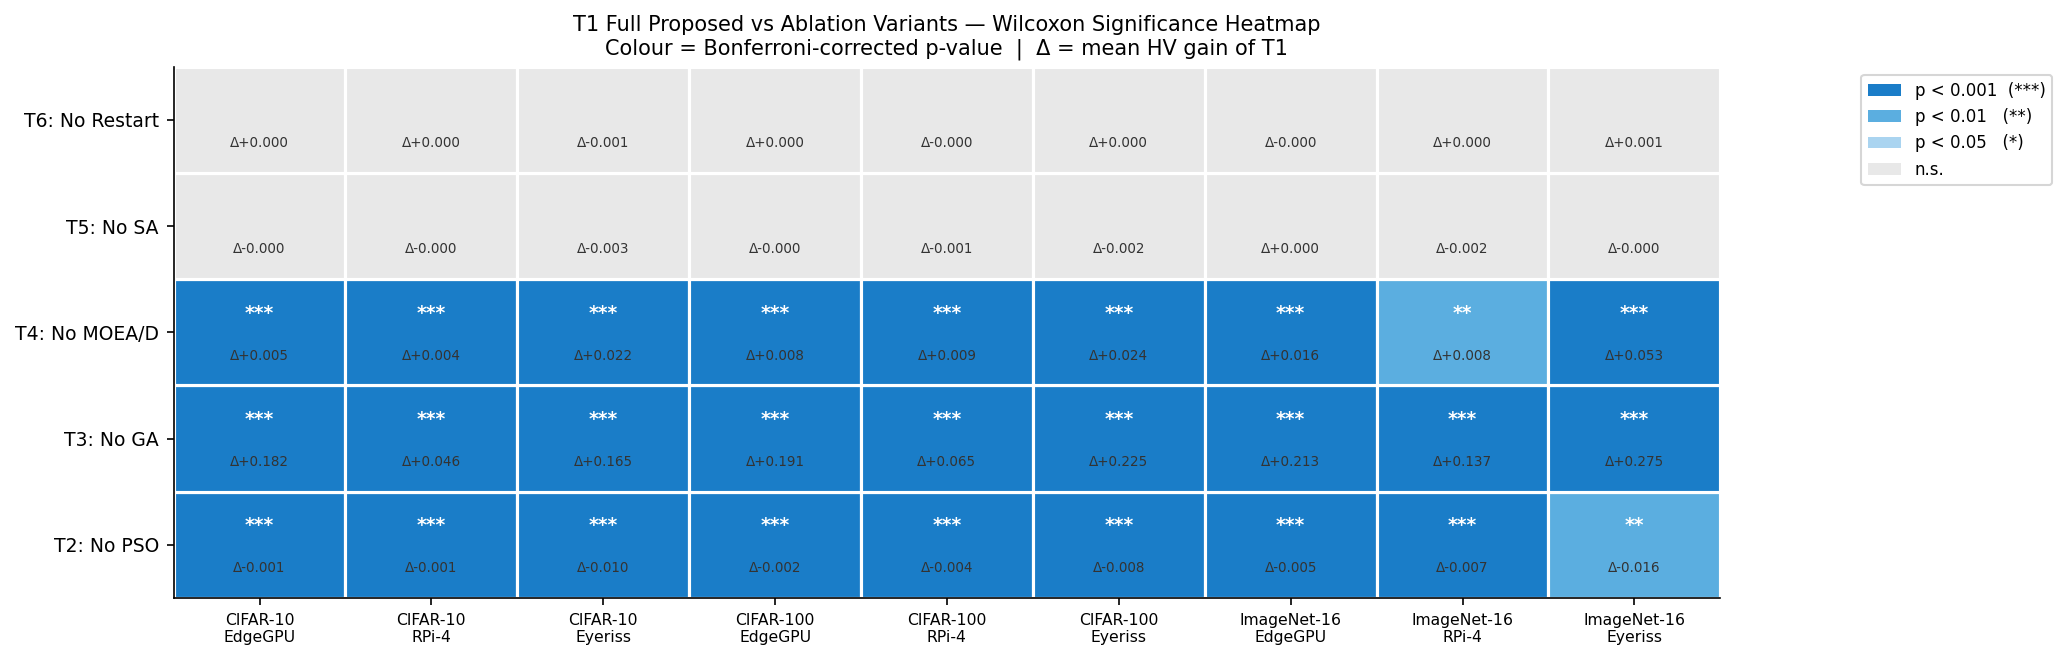

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/ablation/ablation_significance_heatmap.pdf


In [8]:
# ── Cell 8: Significance heatmap (ablation x combo) ────────────────────────
ablation_lbls = [EXP_LABELS[n] for n in EXP_NAMES[1:]]  # T2–T6
combo_lbls    = [f'{DS_LABEL[ds]}\n{HW_LABEL[hw]}'
                 for ds in DATASETS for hw in HARDWARE]   # 9 combos

p_matrix     = np.ones((len(ablation_lbls), len(combo_lbls)))
delta_matrix = np.zeros_like(p_matrix)
for j, (ds, hw) in enumerate([(d, h) for d in DATASETS for h in HARDWARE]):
    for i, name in enumerate(EXP_NAMES[1:]):
        row = df_stats[(df_stats['ds_key'] == ds) &
                       (df_stats['hw_key'] == hw) &
                       (df_stats['exp_name'] == name)]
        if not row.empty:
            p_matrix[i, j]     = row.iloc[0]['p_bonf']
            delta_matrix[i, j] = row.iloc[0]['delta_hv']

def _sig_color(p):
    if   p < 0.001: return '#1a7dc8'
    elif p < 0.01:  return '#5baee0'
    elif p < 0.05:  return '#aad4f0'
    else:           return '#e8e8e8'

fig_h, ax_h = plt.subplots(figsize=(14, 4.5))
nr, nc = p_matrix.shape
for i in range(nr):
    for j in range(nc):
        color = _sig_color(p_matrix[i, j])
        rect  = plt.Rectangle([j - 0.5, i - 0.5], 1, 1,
                               facecolor=color, edgecolor='white', lw=1.5)
        ax_h.add_patch(rect)
        if p_matrix[i, j] < 0.05:
            stars = ('***' if p_matrix[i, j] < 0.001 else
                     '**'  if p_matrix[i, j] < 0.01  else '*')
            ax_h.text(j, i + 0.18, stars, ha='center', va='center',
                      fontsize=9, fontweight='bold', color='white')
        ax_h.text(j, i - 0.22, f'\u0394{delta_matrix[i, j]:+.3f}',
                  ha='center', va='center', fontsize=6.5, color='#333')

ax_h.set_xlim(-0.5, nc - 0.5)
ax_h.set_ylim(-0.5, nr - 0.5)
ax_h.set_xticks(range(nc))
ax_h.set_xticklabels(combo_lbls, fontsize=7.5)
ax_h.set_yticks(range(nr))
ax_h.set_yticklabels(ablation_lbls, fontsize=9)
ax_h.set_title(
    'T1 Full Proposed vs Ablation Variants \u2014 Wilcoxon Significance Heatmap\n'
    'Colour = Bonferroni-corrected p-value  |  \u0394 = mean HV gain of T1',
    fontsize=10,
)
legend_patches = [
    mpatches.Patch(facecolor='#1a7dc8', label='p < 0.001  (***)'),
    mpatches.Patch(facecolor='#5baee0', label='p < 0.01   (**)'),
    mpatches.Patch(facecolor='#aad4f0', label='p < 0.05   (*)'),
    mpatches.Patch(facecolor='#e8e8e8', label='n.s.'),
]
ax_h.legend(handles=legend_patches, loc='upper right',
            bbox_to_anchor=(1.22, 1.0), fontsize=8)
fig_h.tight_layout()
save_hm = OUT_DIR / 'ablation_significance_heatmap.pdf'
plt.savefig(save_hm, bbox_inches='tight')
plt.show()
print(f'Saved: {save_hm}')


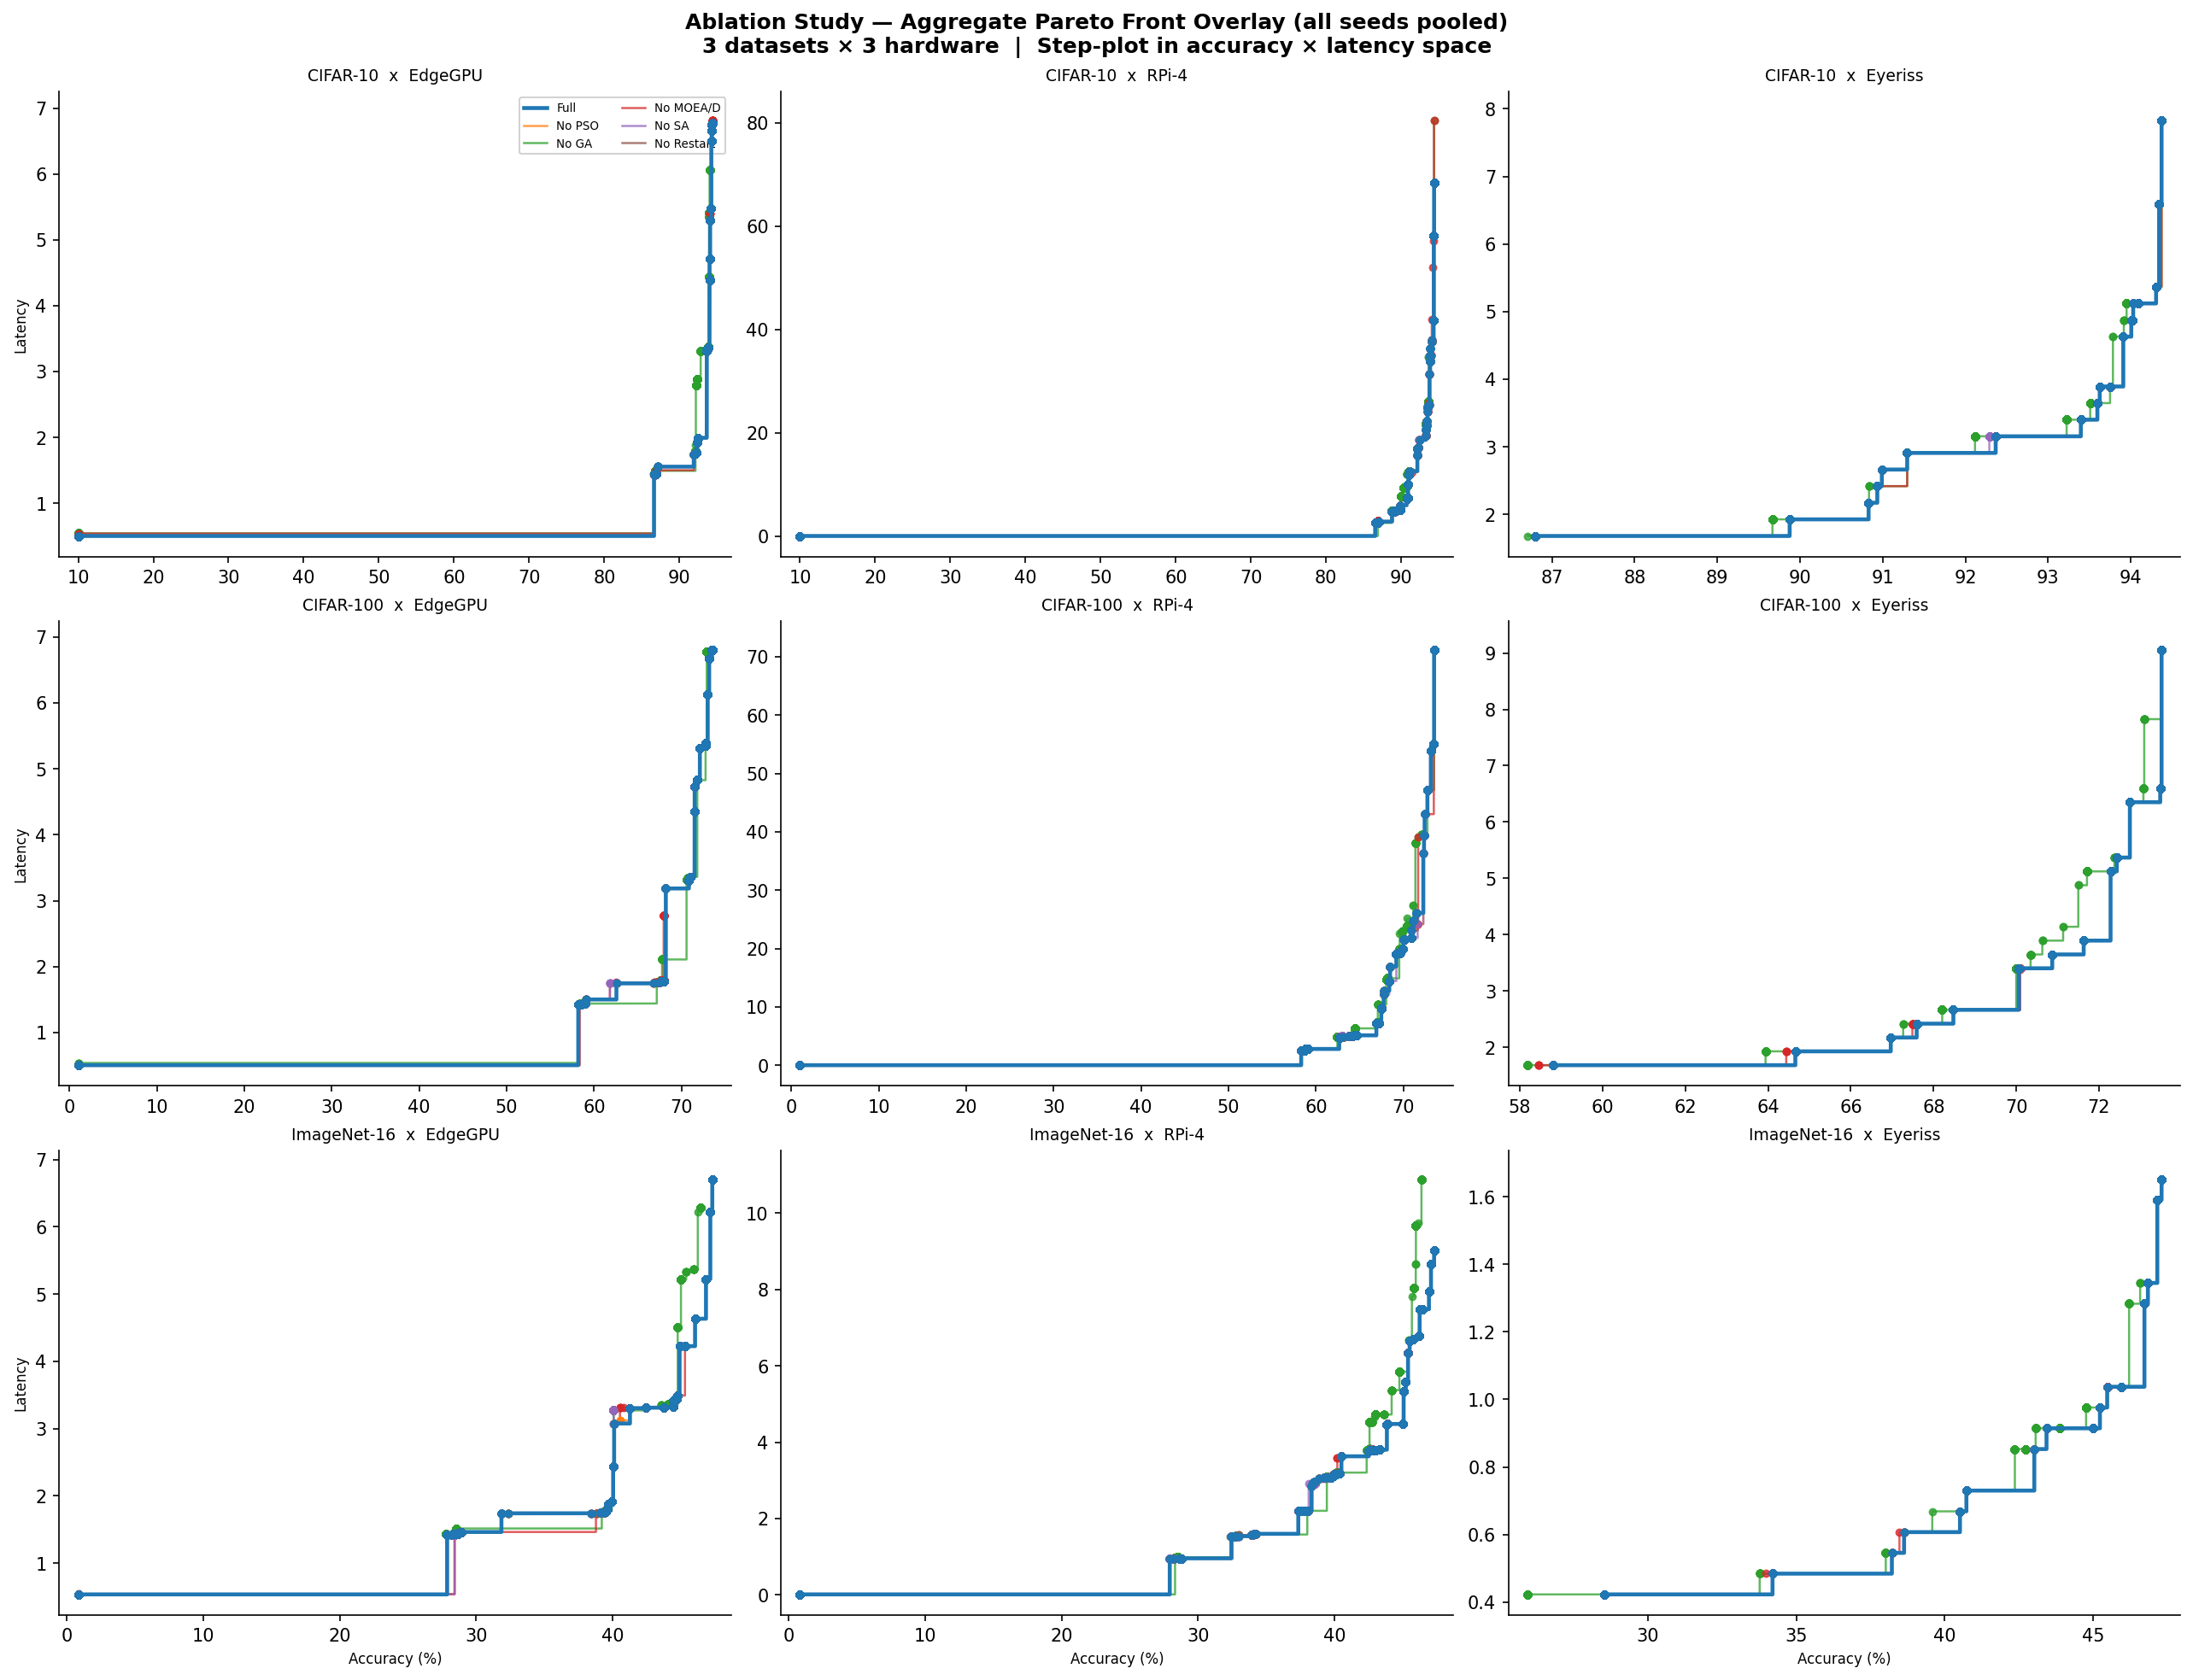

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/ablation/ablation_pareto_3x3.pdf


In [9]:
# ── Cell 9: 3x3 Aggregate Pareto front overlay ──────────────────────────────
fig_p, axes_p = plt.subplots(3, 3, figsize=(17, 13), constrained_layout=True)
fig_p.suptitle(
    'Ablation Study \u2014 Aggregate Pareto Front Overlay (all seeds pooled)\n'
    '3 datasets \u00d7 3 hardware  |  Step-plot in accuracy \u00d7 latency space',
    fontsize=12, fontweight='bold',
)

# Shared legend (built from first valid panel)
legend_built = False

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax = axes_p[r, c]

        all_acc, all_lat, lines = [], [], []
        for name in EXP_NAMES:
            arcs = available[ds][hw].get(name, [])
            if not arcs:
                continue
            try:
                all_pts = np.vstack([archive_to_points(a) for a in arcs])
            except ValueError:
                continue
            front = get_pareto_front(all_pts)
            acc   = -front[:, 0]   # negate F1 → accuracy
            lat   =  front[:, 1]
            order = np.argsort(acc)
            acc, lat = acc[order], lat[order]
            all_acc.append(acc)
            all_lat.append(lat)
            lines.append((name, acc, lat))

        if not lines:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_title(f'{DS_LABEL[ds]}  x  {HW_LABEL[hw]}', fontsize=8)
            continue

        x_all = np.concatenate(all_acc)
        y_all = np.concatenate(all_lat)
        xrng  = max(x_all.max() - x_all.min(), 0.1)
        yrng  = max(y_all.max() - y_all.min(), 1e-6)
        ax.set_xlim(x_all.min() - xrng * 0.03, x_all.max() + xrng * 0.03)
        ax.set_ylim(y_all.min() - yrng * 0.05, y_all.max() + yrng * 0.07)

        for name, acc, lat in lines:
            is_t1 = name == 'full_proposed'
            ax.step(acc, lat, where='post',
                    color=COLORS[name], linewidth=2.2 if is_t1 else 1.2,
                    alpha=1.0 if is_t1 else 0.75,
                    label=EXP_SHORT[name], zorder=10 if is_t1 else 5)
            ax.scatter(acc, lat, s=14, color=COLORS[name],
                       alpha=1.0 if is_t1 else 0.75,
                       zorder=11 if is_t1 else 6)

        ax.set_title(f'{DS_LABEL[ds]}  x  {HW_LABEL[hw]}', fontsize=9)
        if c == 0:
            ax.set_ylabel('Latency', fontsize=8)
        if r == 2:
            ax.set_xlabel('Accuracy (%)', fontsize=8)
        if not legend_built:
            ax.legend(fontsize=6.5, loc='upper right', ncol=2, framealpha=0.85)
            legend_built = True

save_p = OUT_DIR / 'ablation_pareto_3x3.pdf'
plt.savefig(save_p, bbox_inches='tight')
plt.show()
print(f'Saved: {save_p}')
